<a href="https://colab.research.google.com/github/Adityawaghma/End-to-end-supply-chain-analysis/blob/main/end_to_end_supply_chain_analysis_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bussiness Problem**

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

**Desired Outcome:**

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as m
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
viridis_colors = m.viridis (np.linspace(0, 1, 5))
primary_color = viridis_colors [0]
secondary_color = viridis_colors [1]
accent_color = viridis_colors [2]
danger_color = '#800000'
neutral_color = viridis_colors [4]
custom_palette = viridis_colors

In [3]:
df=pd.read_csv("/content/DataCoSupplyChainDataset.csv",encoding='latin1')

In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [5]:
# Overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values (ascending=False).head(20))

rows, cols: (4010, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product 

#Exploratory Data Analysis

In [6]:

# Data Cleaning
columns_to_drop = [
'Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Discount Rate',
'Order Item Product Price',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Benefit per order', # identical to Order Profit Per Order
'Product Status', # have only one value,
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market']

# dropping columns that are either fully missing, redundant ,or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

#removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df= df [df['Delivery Status'] != 'Shipping canceled']

#Standard date conversion

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
   df [c] =pd.to_datetime(df[c], errors='coerce', dayfirst=False)

#after data cleaning, let's check the overview again to see how the dataset has changed

print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (3790, 20)

Missing values (top 5):
Product Name                  1
Product Price                 1
Order Item Profit Ratio       1
order date (DateOrders)       1
shipping date (DateOrders)    1
dtype: int64


In [7]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [8]:
#value counts for categorical columns with low cardinality
for col in df.columns:
  if df[col].nunique() < 10:
    print(f'\n(col)value counts:')
    print(df[col].value_counts())


(col)value counts:
Type
DEBIT       1595
TRANSFER     896
PAYMENT      831
CASH         468
Name: count, dtype: int64

(col)value counts:
Days for shipping (real)
2    1052
5     671
3     651
4     651
6     642
1      71
0      52
Name: count, dtype: int64

(col)value counts:
Days for shipment (scheduled)
4    2278
2    1005
1     384
0     123
Name: count, dtype: int64

(col)value counts:
Delivery Status
Late delivery       2163
Advance shipping     927
Shipping on time     700
Name: count, dtype: int64

(col)value counts:
Late_delivery_risk
1    2163
0    1627
Name: count, dtype: int64

(col)value counts:
Customer Country
Puerto Rico    2240
EE. UU.        1550
Name: count, dtype: int64

(col)value counts:
Customer Segment
Consumer       1811
Corporate      1198
Home Office     781
Name: count, dtype: int64

(col)value counts:
Order Status
COMPLETE           1442
PENDING_PAYMENT     797
PROCESSING          498
CLOSED              468
PENDING             398
ON_HOLD             152

In [9]:
# calculating order processing time and delay
df ['Order Processing Time'] =(df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df ['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df ['Is_Delayed'] = df ['Delay'] > 0
df ['order_month'] = df['order date (DateOrders)'].dt.month
df ['order_day'] = df['order date (DateOrders)'].dt.day_name()
df ['order_hour'] = df['order date (DateOrders)'].dt.hour
df. describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,3790.000000,3790.000000,3790.000000,3790.000000,3789,3789.000000,3789.000000,3789.000000,3789.000000,3789,3789.000000,3789.000000,3789.000000,3789.000000
mean,3.677836,3.035884,182.065508,0.570712,2016-07-23 17:51:19.841646592,0.111781,203.157480,20.823587,136.716738,2016-07-27 10:04:26.539984128,3.659541,0.623911,6.602006,11.362101
min,0.000000,0.000000,9.260000,0.000000,2015-01-01 19:58:00,-2.750000,11.290000,-989.950012,11.290000,2015-01-04 16:17:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,95.764997,0.000000,2015-09-23 01:54:00,0.080000,100.000000,5.880000,50.000000,2015-09-27 09:57:00,2.000000,0.000000,3.000000,5.000000
50%,4.000000,4.000000,145.559998,1.000000,2016-07-16 10:46:00,0.270000,159.960007,28.879999,59.990002,2016-07-18 20:56:00,4.000000,1.000000,7.000000,11.000000
75%,5.000000,4.000000,268.760010,1.000000,2017-05-19 10:31:00,0.360000,299.980011,65.510002,129.990005,2017-05-22 16:18:00,5.000000,2.000000,10.000000,17.000000
max,6.000000,4.000000,1417.500000,1.000000,2018-01-31 22:56:00,0.500000,1500.000000,599.250000,1500.000000,2018-02-05 14:43:00,6.000000,4.000000,12.000000,23.000000
std,1.556166,1.250085,129.099389,0.495040,NaN,0.474510,144.015053,104.290324,145.072035,NaN,1.593844,1.598828,3.757282,6.889940


In [10]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,2092
False,1698


In [11]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [12]:
df['Order Profit Per Order']>0

,Order Profit Per Order
0,True
1,False
2,False
3,True
4,True
...,...
4005,True
4006,True
4007,False
4008,True


In [13]:
import numpy as np

# Create Profitability Flag
df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 'Profit',
    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-Even')
)

In [14]:
# Check the distribution
df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,3042
Loss,726
Break-Even,22


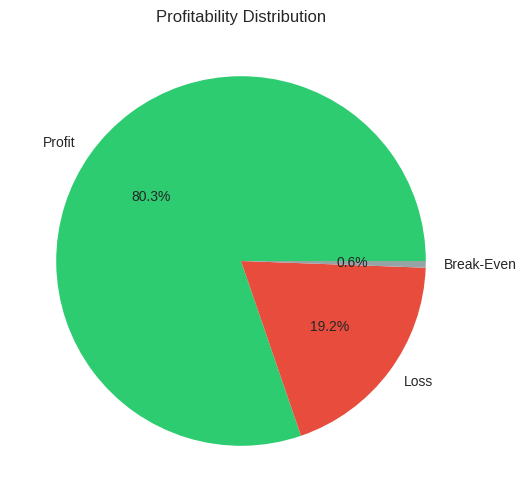

In [15]:
import matplotlib.pyplot as plt

# Assuming you have profit_counts from before
profit_counts = df['Profitability Flag'].value_counts()

# Define colors
accent_color = '#2ecc71'
danger_color = '#e74c3c'
secondary_color = '#95a5a6'

# Create pie chart
profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color],
    figsize=(8, 6)
)
plt.ylabel('')
plt.title('Profitability Distribution')
plt.show()

In [16]:
def format_func(value):
    if value >= 1e6:
        return f'{(value/1e6):.1f}M $'
    elif value >= 1e3:
        return f'{(value/1e3):.1f}K $'
    else:
        return f'{value:.0f} $'
delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics ['Total Orders'] = len(df)
metrics ['Late Deliveries'] = len(delayed_df)
metrics ['90% Delay (days)'] = delayed_df ['Delay'].quantile(0.90)
metrics ['On time Delivery %'] = (1 - float(metrics ['Late Deliveries']) / metrics ['Total Orders']) * 100
metrics ['Late Delivery %'] = float(metrics ['Late Deliveries']) / metrics ['Total Orders'] * 100
metrics ['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics ['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())
print('\n-- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


-- Business KPIs ---

Total Orders: 3790
Late Deliveries: 2092
90% Delay (days): 4.00
On time Delivery %: 44.80
Late Delivery %: 55.20
Total Profit: 162.6K $
Total Loss due to delays: 41.5K $


#Profitability vs Delivery Time Analysis

In [17]:
profit_metrics = (
df.groupby ('Delay') ['Order Profit Per Order']
.agg (
mean_profit='mean',
      total_profit='sum',
       order_count='count'
)
.reset_index()
        )

In [18]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2.0,29.293333,13885.040038,474
1,-1.0,16.248407,7344.280106,452
2,0.0,20.915266,16125.670077,771
3,1.0,22.341366,23547.800070,1054
4,2.0,18.045395,11206.190070,621
5,3.0,18.971200,3794.239977,200
6,4.0,13.812673,2997.349987,217


In [19]:
delay_distribution = (
df ['Delay']
.value_counts (normalize=True)
.sort_index()* 100
) .reset_index()

In [20]:
delay_distribution

,Delay,proportion
0,-2.0,12.509897
1,-1.0,11.929269
2,0.0,20.348377
3,1.0,27.817366
4,2.0,16.389549
5,3.0,5.278438
6,4.0,5.727105



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2.0,29.3,13885.0,474
1,-1.0,16.2,7344.3,452
2,0.0,20.9,16125.7,771
3,1.0,22.3,23547.8,1054
4,2.0,18.0,11206.2,621
5,3.0,19.0,3794.2,200
6,4.0,13.8,2997.3,217



Delay Distribution (%):


,Delay_Days,Percentage
0,-2.0,12.509897
1,-1.0,11.929269
2,0.0,20.348377
3,1.0,27.817366
4,2.0,16.389549
5,3.0,5.278438
6,4.0,5.727105


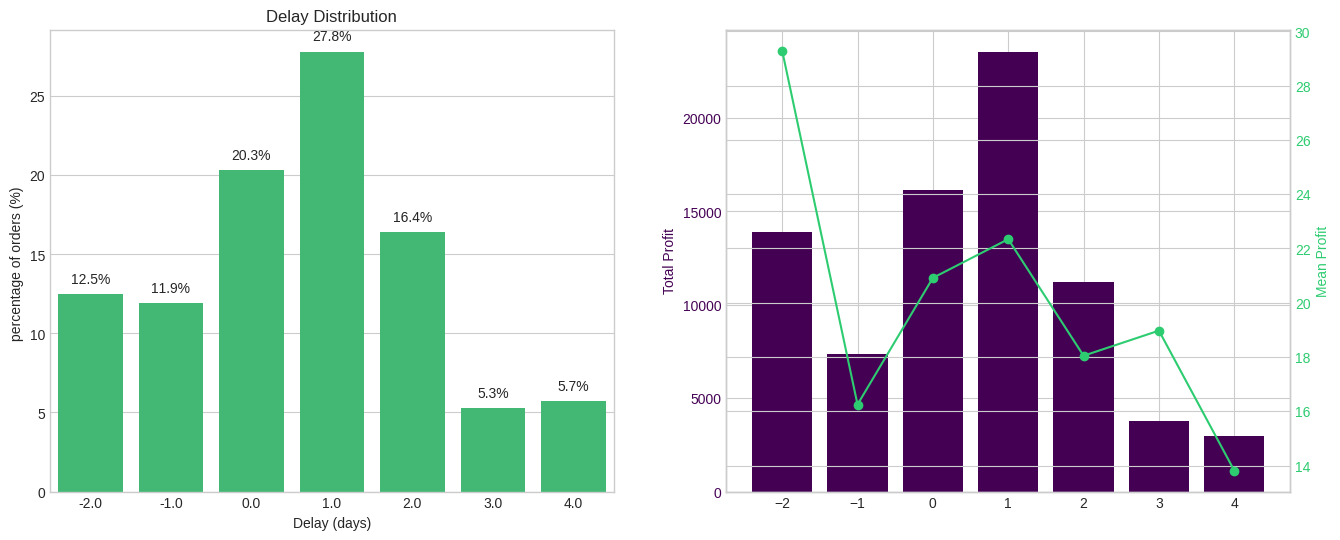

In [21]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%) ')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()

    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%',
     ha='center', va='bottom' )

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()
ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

**Bottleneck Detection**





In [22]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'), late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

In [23]:
compute_delay_pct_by_category ('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
0,Consumer,1811,1041,57.482054
2,Home Office,781,426,54.545455
1,Corporate,1197,625,52.213868


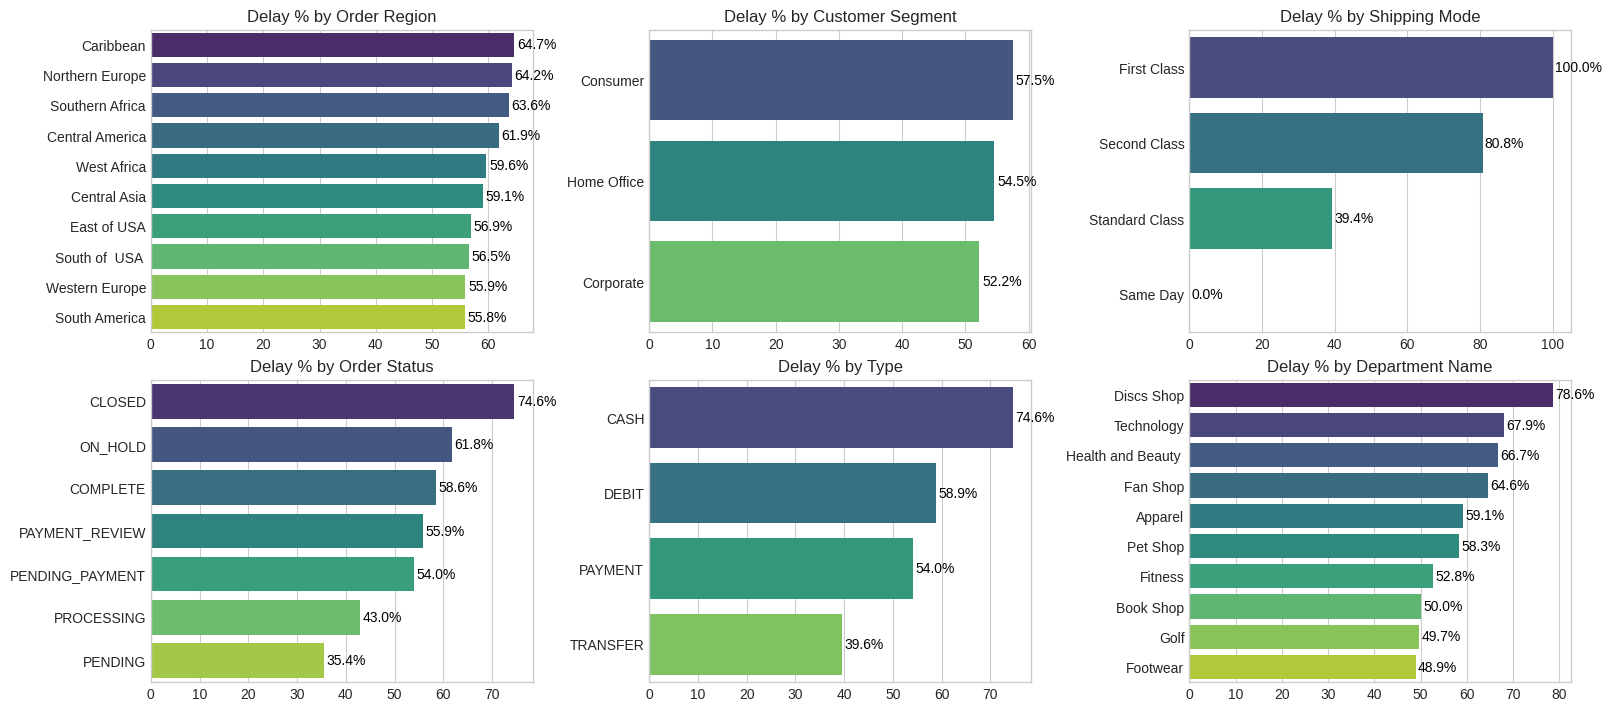

In [24]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'), late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category, ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel('') # Clear the y-label as categories are on y-axis

    for bar in ax.patches:
        width = bar.get_width()
        ax.text(
            width + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            va='center',
            fontsize=10,
            color='black' # Changed to black for better visibility on color background
        )

plt.show()

#Root Cause Analysis


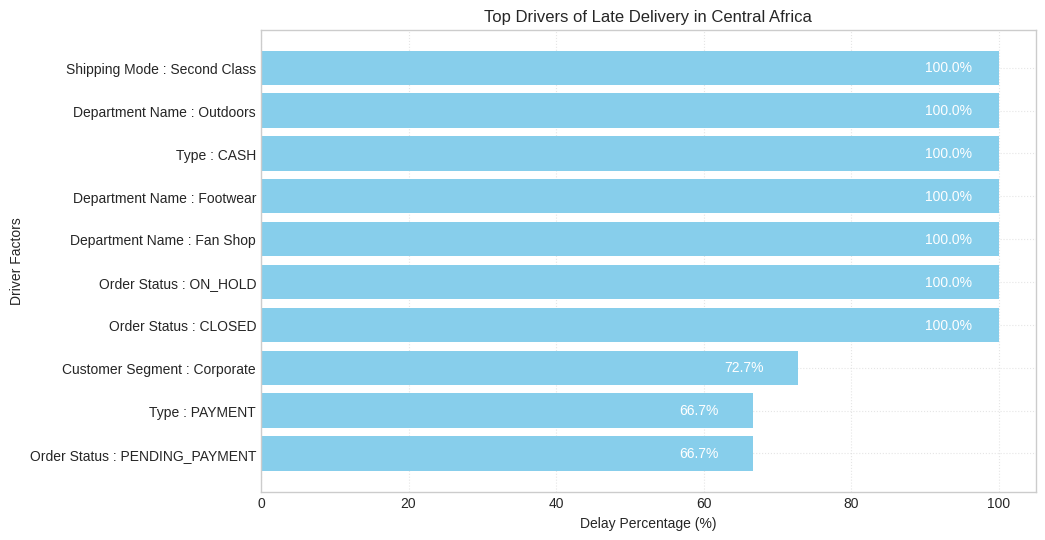

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Top drivers of late delivery by region
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'), late_orders=('Is_Delayed', 'sum'), avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        temp['Driver'] = factor # Added 'Driver' column
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay']])

    # Combine all drivers
    final_df = pd.concat(all_factors)
    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure(figsize=(10, 6)) # Added figsize for better visualization
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color='skyblue')
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                 f"{width:.1f}%",
                 va='center', fontsize=10, color='white')
    plt.show()

top_drivers_for_region('Central Africa')

#Time-Based Analysis

In [26]:
# Delay % by Month, Day of Week, Hour
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

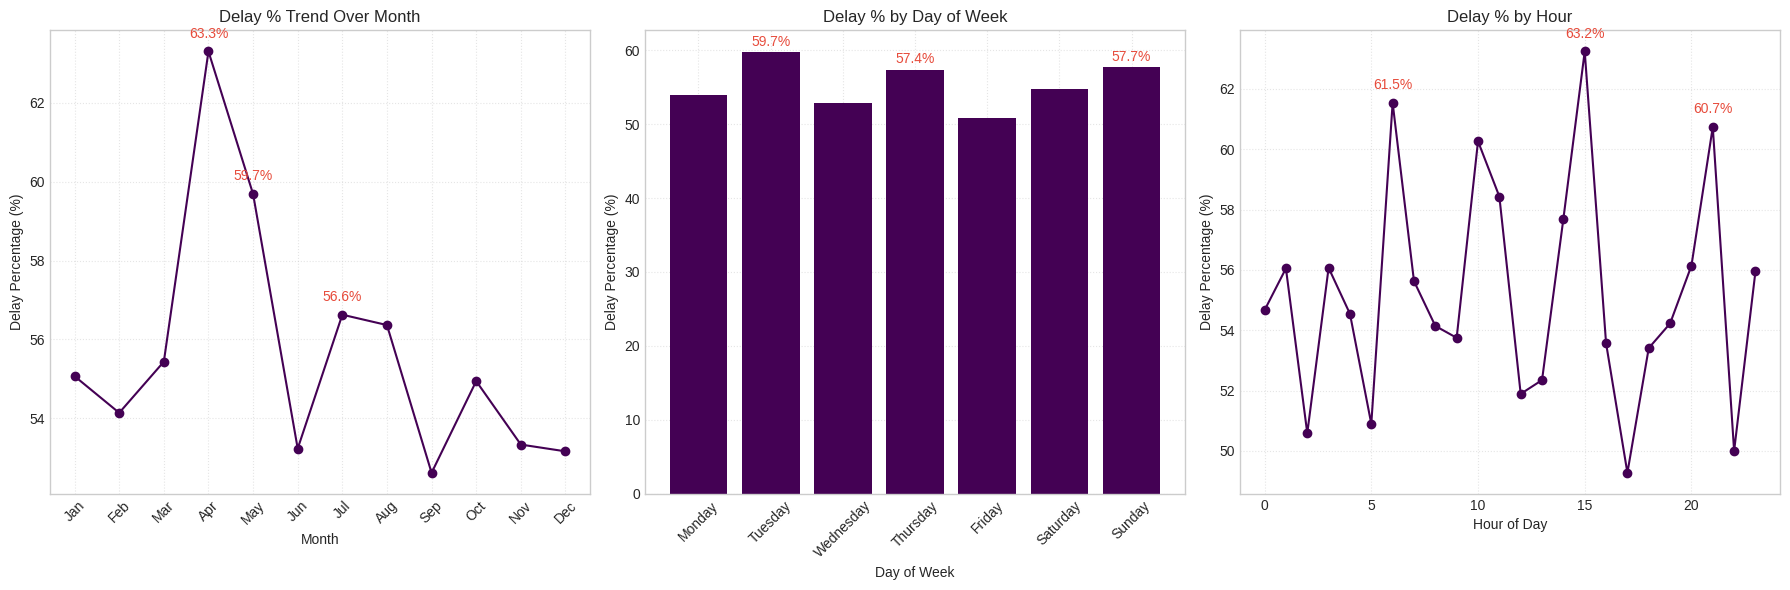

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')
ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

#Machine Learning Modeling

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [29]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment',
      'Department Name', 'Order Region', 'Shipping Mode', 'order_month','order_hour']]
Y = df['Late_delivery_risk']

In [38]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print( 'Categorical columns:', cat_cols)
# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)
# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)
# use encoded features for modeling
X = X_encoded

# Drop rows where X or Y contain NaN values
nan_mask_X = X.isna().any(axis=1)
nan_mask_Y = Y.isna()
combined_nan_mask = nan_mask_X | nan_mask_Y

if combined_nan_mask.any():
    num_nan_rows = combined_nan_mask.sum()
    print(f"Dropping {num_nan_rows} rows with NaN values in X or Y.")
    X = X[~combined_nan_mask]
    Y = Y[~combined_nan_mask]

# train/test split after encoding
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

Categorical columns: []
Shape after freq+target encoding: (3790, 9)
Dropping 1 rows with NaN values in X or Y.


In [31]:
Y_train.value_counts()

,count
Late_delivery_risk,
1,1730
0,1302


In [39]:
# Balancing the training data using SMOTE
print ("Before balancing (train):", Counter(Y_train))

# Explicitly drop any remaining NaNs from X_train and corresponding Y_train
# This ensures SMOTE receives a clean dataset, addressing the ValueError.
initial_X_train_shape = X_train.shape

# Temporarily combine X_train and Y_train to drop rows with NaNs across both
temp_train_df = pd.concat([X_train, Y_train.rename('target')], axis=1) # Rename Y_train for concat
temp_train_df.dropna(inplace=True)

X_train = temp_train_df.drop(columns=['target'])
Y_train = temp_train_df['target']

if X_train.shape[0] < initial_X_train_shape[0]:
    print(f"Warning: Dropped {initial_X_train_shape[0] - X_train.shape[0]} rows from X_train/Y_train due to NaNs right before SMOTE.")

smote = SMOTE (random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)
print("After balancing (train):", Counter(Y_train_bal))

Before balancing (train): Counter({1: 1730, 0: 1301})
After balancing (train): Counter({0: 1730, 1: 1730})


In [35]:
def evaluate_model (y_true, y_pred, model_name) :
    print (f"\n--- {model_name} ---")
    print ("Accuracy:", round (accuracy_score(y_true, y_pred) ,2))
    print("Precision:"
    , round (precision_score(y_true, y_pred) ,2))
    print ("Recall:", round (recall_score(y_true, y_pred) ,2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [40]:
# fit the random forest on blanced data
rf_model_balanced = RandomForestClassifier (random_state=42)
rf_model_balanced. fit(X_train_bal, Y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)
evaluate_model(Y_test, y_pred_rf_balanced,
"Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.7
Precision: 0.75
Recall: 0.71

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.68      0.66       325
           1       0.75      0.71      0.73       433

    accuracy                           0.70       758
   macro avg       0.69      0.70      0.70       758
weighted avg       0.70      0.70      0.70       758

